NHANES Body Mesurement Analysis
Capstine Project 1
Name: Parammeet

Objective
This project analyzes body measurement of adult male and female participants from the NHANES dataset using NumPy,Pandas,Matplotlib,and Seaborn

The project includes: -Data visualization -Statistical analysis' -BMI calculation -Z-score Standarsiztion -Coreletion analysis -Waist-to-height ratio analysis -Waist-to-hip ratio analysid

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis

import warnings
warnings.filterwarnings('ignore')
print("Library loaded successfully")

Library loaded successfully


## Loading the  Dataset

In [27]:
male = pd.read_csv("nhanes_adult_male_bmx_2020.csv",comment="#")
female = pd.read_csv("nhanes_adult_female_bmx_2020.csv",comment="#")

print("Male Shape:",male.shape)
print("Female Shape:",female.shape)

Male Shape: (4081, 7)
Female Shape: (4221, 7)


In [28]:
print("Male Datsdrt Columes")
print(male.columns)

print("\n Female Data Columes")
print(female.columns)

Male Datsdrt Columes
Index(['BMXWT', 'BMXHT', 'BMXARML', 'BMXLEG', 'BMXARMC', 'BMXHIP', 'BMXWAIST'], dtype='object')

 Female Data Columes
Index(['BMXWT', 'BMXHT', 'BMXARML', 'BMXLEG', 'BMXARMC', 'BMXHIP', 'BMXWAIST'], dtype='object')


In [29]:
male.head()

,BMXWT,BMXHT,BMXARML,BMXLEG,BMXARMC,BMXHIP,BMXWAIST
0,98.8,182.3,42.0,40.1,38.2,108.2,120.4
1,74.3,184.2,41.1,41.0,30.2,94.5,86.8
2,103.7,185.3,47.0,44.0,32.0,107.8,109.6
3,86.0,167.8,39.5,38.4,29.0,106.4,108.3
4,99.4,181.6,40.4,39.9,36.0,120.2,107.0


In [30]:
female.head()

,BMXWT,BMXHT,BMXARML,BMXLEG,BMXARMC,BMXHIP,BMXWAIST
0,97.1,160.2,34.7,40.8,35.8,126.1,117.9
1,91.1,152.7,33.5,33.0,38.5,125.5,103.1
2,73.0,161.2,37.4,38.0,31.8,106.2,92.0
3,61.7,157.4,38.0,34.7,29.0,101.0,90.5
4,55.4,154.6,34.6,34.0,28.3,92.5,73.2


##Conversion to NumPy Matrices

In [31]:
male_matrix = male.to_numpy()
female_matrix = female.to_numpy()

print("Male Matrix Shape:",male_matrix.shape)
print("Female Matrix Shape:",female_matrix.shape)

Male Matrix Shape: (4081, 7)
Female Matrix Shape: (4221, 7)


## Exteacting Weight Measurements

first column in each dataset contains body weight in kilograms.

In [32]:
male_weights = male_matrix[:,0]
female_weights = female_matrix[:,0]

print("First 10 Male Weights:")
print(male_weights[:10])

print("\nFirst 10 Female Weights:")
print(female_weights[:10])

First 10 Male Weights:
[ 98.8  74.3 103.7  86.   99.4  90.2  45.5  64.   67.9  75.2]

First 10 Female Weights:
[97.1 91.1 73.  61.7 55.4 62.  66.2 75.9 77.2 91.6]


#Histogram for weight Distribution

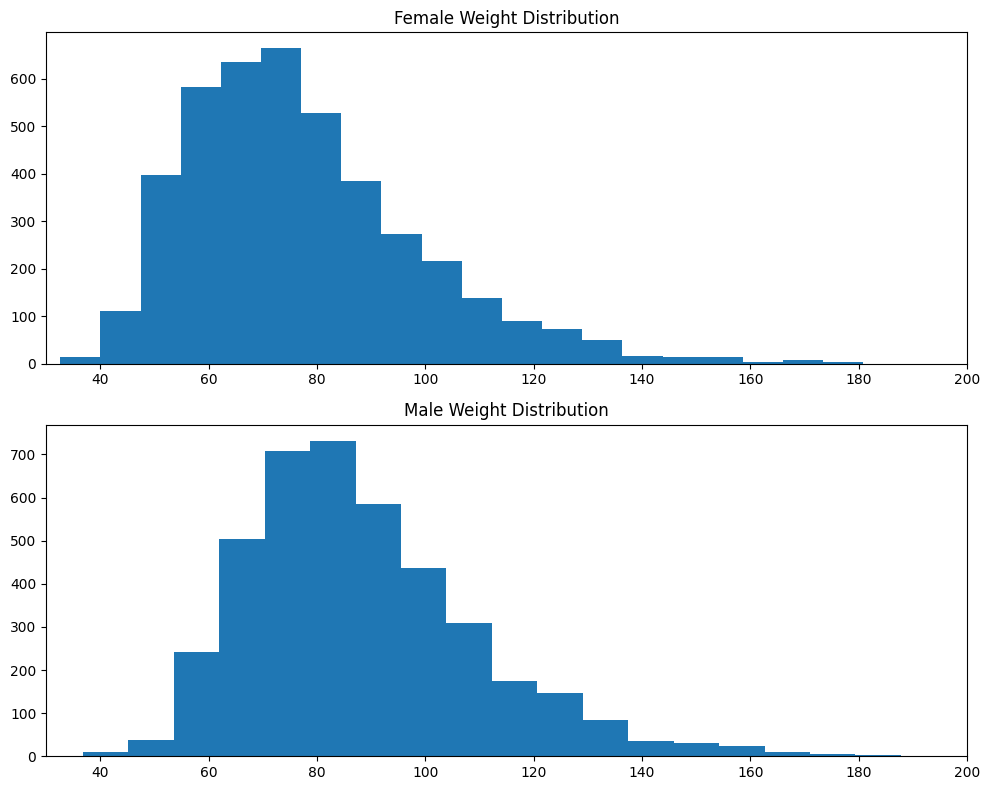

In [33]:
plt.figure(figsize=(10,8))
plt.subplot(2,1,1)
plt.hist(female_weights,bins=20)
plt.title("Female Weight Distribution")
plt.xlim(30,200)

plt.subplot(2,1,2)
plt.hist(male_weights, bins = 20)
plt.title("Male Weight Distribution")
plt.xlim(30,200)

plt.tight_layout()
plt.show()

Male participents generally have higher body weight then female particepents.
Most observaltion are concatinated around the middle weight renges, While the small number of particepents have very high body weights.

##Comparing male and female weights

A Boxplot provides a compact summary of a distribution by displaying:
-Median
-Quartiles
-Range
-outliers

This allow a easy comparision between male and female body weights.

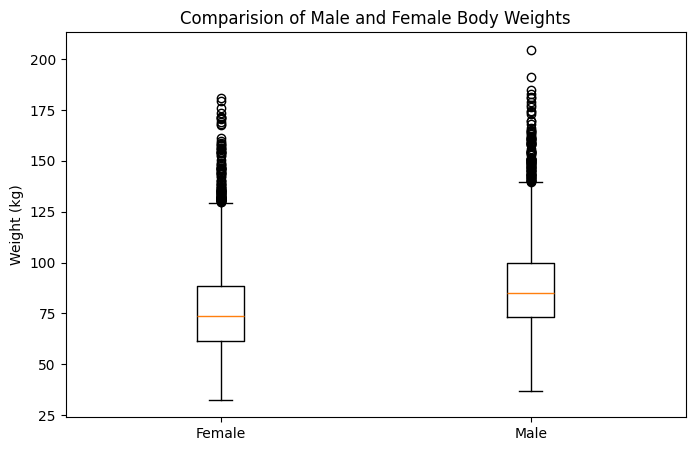

In [34]:
plt.figure(figsize=(8,5))

plt.boxplot([female_weights, male_weights],labels=["Female","Male"])
plt.title("Comparision of Male and Female Body Weights")
plt.ylabel("Weight (kg)")
plt.show()

### Discussion

The boxplot shows that male participants generally have a higher median weight than female participants.

The spread of male weights is also slightly larger, indicating greater variability.

Several outliers are present in both groups, representing participants with unusually high body weights.

## Statisticle analysis

## Numerical Summary of Weight Distributions

To better understand the distributions, several statistical measures are calculated:

- Mean
- Median
- Standard Deviation
- Minimum
- Maximum
- Skewness
- Kurtosis

These measures describe the center, spread, and shape of the data.

In [35]:
from scipy.stats import skew
from scipy.stats import kurtosis
def describe_weights(data, group_name):

    print("\n" + "="*40)
    print(group_name)
    print("="*40)

    print("Mean:", np.mean(data))
    print("Median:", np.median(data))
    print("Standard Deviation:", np.std(data))
    print("Minimum:", np.min(data))
    print("Maximum:", np.max(data))
    print("Skewness:", skew(data))
    print("Kurtosis:", kurtosis(data))

In [36]:
describe_weights(female_weights, "Female Weight Statistics")

describe_weights(male_weights, "Male Weight Statistics")


Female Weight Statistics
Mean: 77.40379057095475
Median: 73.6
Standard Deviation: 21.54250829019315
Minimum: 32.6
Maximum: 180.9
Skewness: 1.03336107186799
Kurtosis: 1.4009683480659731

Male Weight Statistics
Mean: 88.36454300416565
Median: 85.0
Standard Deviation: 21.418936717962495
Minimum: 36.8
Maximum: 204.6
Skewness: 0.9842810741662347
Kurtosis: 1.4742884754078238


### Discussion

The mean and median values provide information about the central tendency of the data.

The standard deviation indicates the amount of variability within each group.

Positive skewness suggests that a small number of participants have very large body weights.

The kurtosis values provide information about the presence of extreme observations.

## Body Mass Index (BMI)

Body Mass Index (BMI) is a commonly used measure that relates body weight to body height.

BMI is calculated using:

BMI = Weight (kg) / Height² (m²)

The BMI values are added as a new column to the female dataset.

In [37]:
female_weight = female_matrix[:, 0]

female_height = female_matrix[:, 1] / 100

female_bmi = female_weight / (female_height ** 2)
print(female_bmi[:10])

[37.83504078 39.06972037 28.09265496 24.90437849 23.17879132 29.61110588
 23.87973559 31.796902   30.46008939 30.08185483]


In [38]:
female_matrix = np.column_stack(
    (female_matrix, female_bmi)
)

print("New Female Matrix Shape:")
print(female_matrix.shape)

New Female Matrix Shape:
(4221, 8)


### Observation

A new BMI column has been successfully added to the female dataset.

The dataset now contains eight variables.

## Standardization of Variables

The variables have different scales and units.

To make them directly comparable, z-score standardization is applied.

A z-score indicates how many standard deviations a value is above or below the mean.

In [39]:
zfemale = (
    female_matrix - np.mean(female_matrix, axis=0)
) / np.std(female_matrix, axis=0)

In [40]:
print(zfemale.shape)

zfemale[:5]

(4221, 8)


array([[ 0.91429508,  0.00895038, -0.56739463,  1.13298804,  0.55084546,
         1.08316157,  1.11578462,  0.9969677 ],
       [ 0.63577599, -1.05306843, -1.07893145, -1.29349161,  1.03221804,
         1.04475528,  0.265089  ,  1.15617483],
       [-0.2044233 ,  0.15055289,  0.5835632 ,  0.26194406, -0.1622991 ,
        -0.19064688, -0.37293272, -0.25927501],
       [-0.7289676 , -0.38753664,  0.83933161, -0.76464348, -0.66150029,
        -0.52350135, -0.45915188, -0.67039085],
       [-1.02141265, -0.78402366, -0.6100227 , -0.98240447, -0.78630059,
        -1.06759039, -1.45354609, -0.89289859]])

### Observation

After standardization, all variables have approximately the same scale.

The standardized values can now be compared directly across variables.

## Preparing Standardized Variables

To analyze relationships between body measurements, a subset of standardized variables is selected.

The following variables are included:

- Weight
- Height
- Hip Circumference
- Waist Circumference
- BMI

In [41]:
selected_df = pd.DataFrame({
    "Weight": zfemale[:, 0],
    "Height": zfemale[:, 1],
    "Hip": zfemale[:, 5],
    "Waist": zfemale[:, 6],
    "BMI": zfemale[:, 7]
})

selected_df.head()

,Weight,Height,Hip,Waist,BMI
0,0.914295,0.008950,1.083162,1.115785,0.996968
1,0.635776,-1.053068,1.044755,0.265089,1.156175
2,-0.204423,0.150553,-0.190647,-0.372933,-0.259275
3,-0.728968,-0.387537,-0.523501,-0.459152,-0.670391
4,-1.021413,-0.784024,-1.067590,-1.453546,-0.892899


## Scatterplot Matrix

A scatterplot matrix helps visualize relationships among multiple variables simultaneously.

Strong relationships appear as clear patterns in the plots.

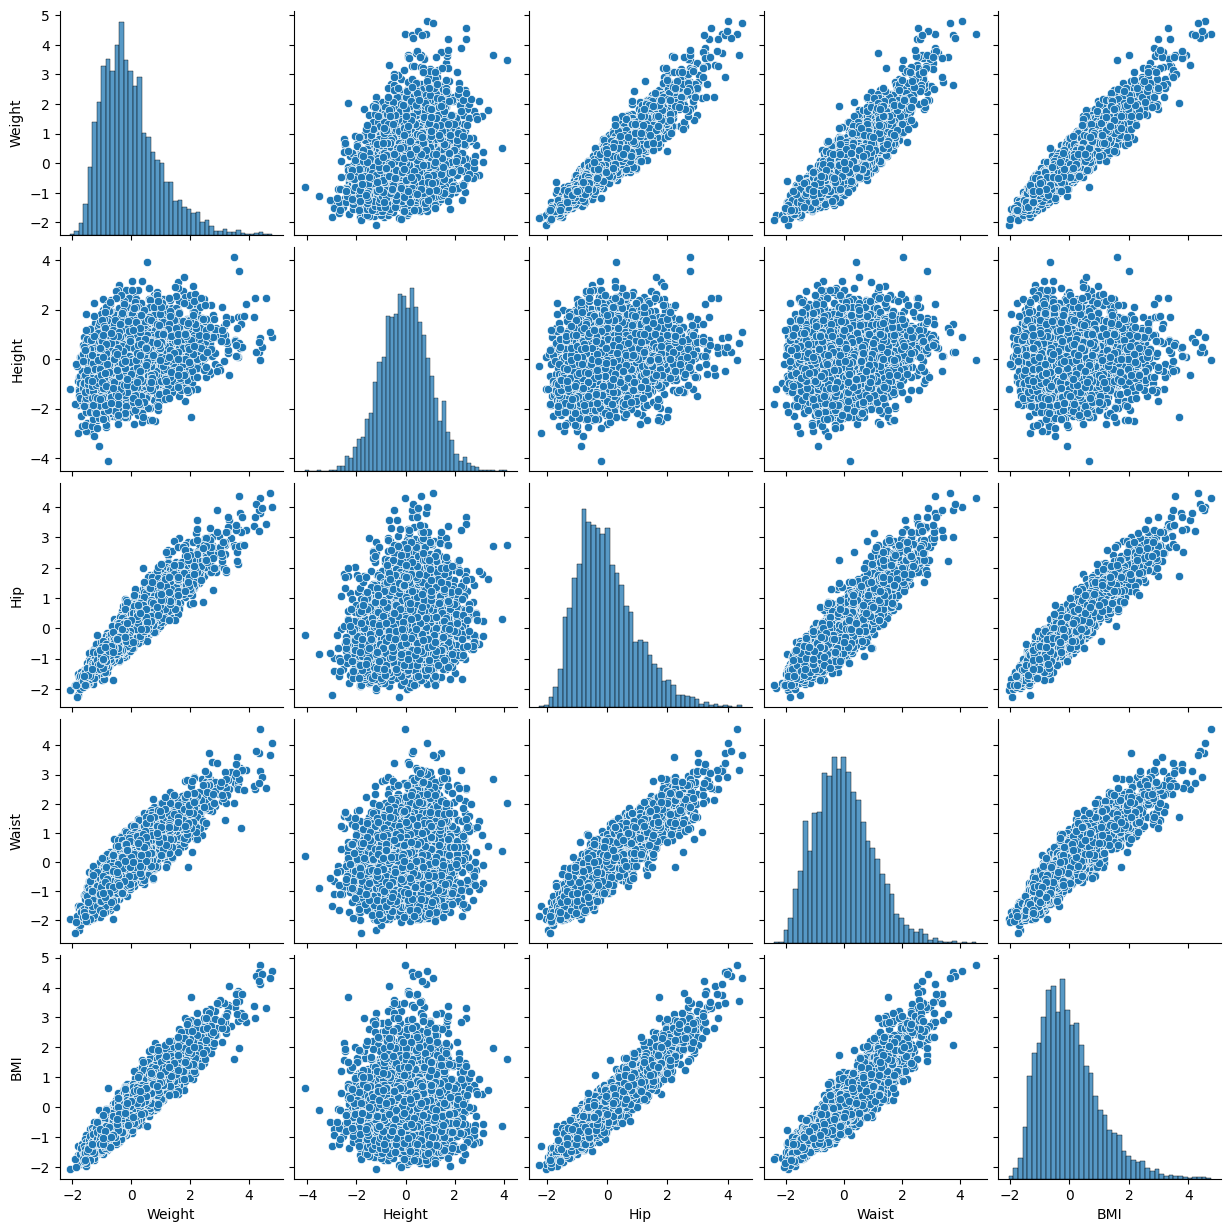

In [42]:
sns.pairplot(selected_df)

plt.show()

### Discussion

The scatterplots indicate positive relationships among weight, BMI, waist circumference, and hip circumference.

Participants with higher body weight generally have higher BMI values and larger waist and hip measurements.

## Pearson Correlation Analysis

Pearson correlation measures the strength of linear relationships between variables.

In [43]:
pearson_corr = selected_df.corr(method="pearson")

print(pearson_corr)

          Weight    Height       Hip     Waist       BMI
Weight  1.000000  0.345496  0.946553  0.904550  0.945900
Height  0.345496  1.000000  0.202895  0.126547  0.033077
Hip     0.946553  0.202895  1.000000  0.897407  0.944199
Waist   0.904550  0.126547  0.897407  1.000000  0.921198
BMI     0.945900  0.033077  0.944199  0.921198  1.000000


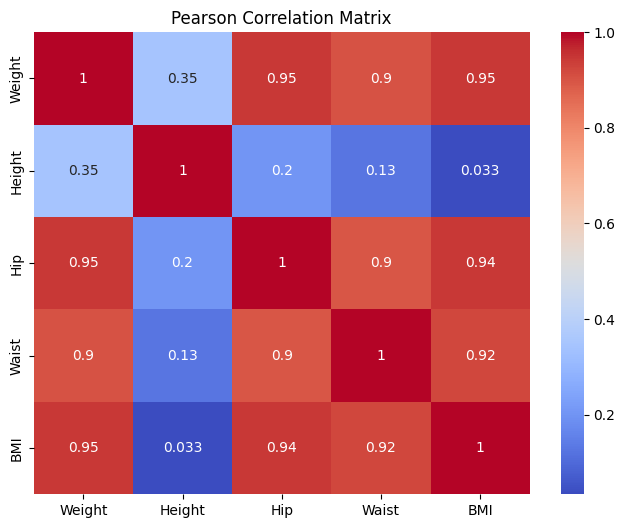

In [44]:
plt.figure(figsize=(8,6))

sns.heatmap(
    pearson_corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Pearson Correlation Matrix")

plt.show()

### Discussion

Strong positive correlations indicate that variables increase together.

BMI shows a particularly strong relationship with body weight and waist circumference.

## Spearman Correlation Analysis

Spearman correlation measures monotonic relationships and is less sensitive to outliers.

In [45]:
spearman_corr = selected_df.corr(method="spearman")

print(spearman_corr)

          Weight    Height       Hip     Waist       BMI
Weight  1.000000  0.338860  0.946634  0.900169  0.937999
Height  0.338860  1.000000  0.205405  0.108587  0.019897
Hip     0.946634  0.205405  1.000000  0.888037  0.934196
Waist   0.900169  0.108587  0.888037  1.000000  0.923114
BMI     0.937999  0.019897  0.934196  0.923114  1.000000


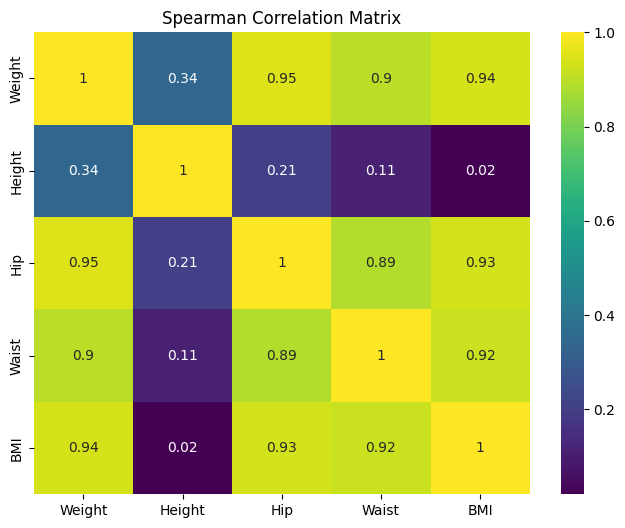

In [46]:
plt.figure(figsize=(8,6))

sns.heatmap(
    spearman_corr,
    annot=True,
    cmap="viridis"
)

plt.title("Spearman Correlation Matrix")

plt.show()

### Discussion

The Spearman coefficients are similar to the Pearson coefficients.

This suggests that the relationships among the variables are strong and consistent.

## Waist-to-Height Ratio

The waist-to-height ratio is calculated by dividing waist circumference by height.

This ratio is often used as an indicator of obesity-related health risk.

In [47]:
male_whr = male_matrix[:, 6] / male_matrix[:, 1]

female_whr = female_matrix[:, 6] / female_matrix[:, 1]

## Waist-to-Hip Ratio

The waist-to-hip ratio compares waist circumference with hip circumference and provides information about fat distribution.

In [48]:
male_whip = male_matrix[:, 6] / male_matrix[:, 5]

female_whip = female_matrix[:, 6] / female_matrix[:, 5]

In [49]:
male_matrix = np.column_stack(
    (male_matrix, male_whr, male_whip)
)

female_matrix = np.column_stack(
    (female_matrix, female_whr, female_whip)
)

print(male_matrix.shape)
print(female_matrix.shape)

(4081, 9)
(4221, 10)


## Comparison of Body Ratios

The distributions of waist-to-height ratio and waist-to-hip ratio are compared for both male and female participants.

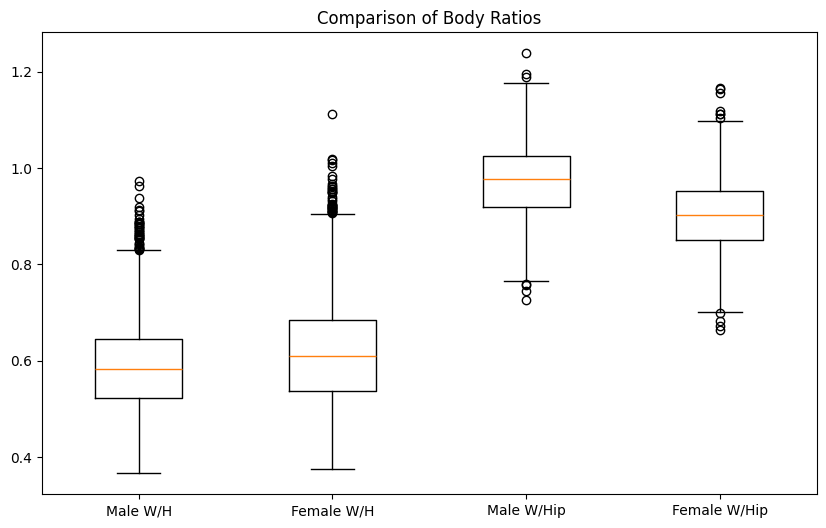

In [50]:
plt.figure(figsize=(10,6))

plt.boxplot([
    male_whr,
    female_whr,
    male_whip,
    female_whip
],
labels=[
    "Male W/H",
    "Female W/H",
    "Male W/Hip",
    "Female W/Hip"
])

plt.title("Comparison of Body Ratios")

plt.show()

### Discussion

The boxplots show differences in body fat distribution between male and female participants.

The waist-to-height ratio and waist-to-hip ratio provide additional information beyond BMI and can help identify obesity-related health risks.

## Advantages and Disadvantages of BMI, Waist-to-Height Ratio, and Waist-to-Hip Ratio

### BMI

Advantages:
- Easy to calculate
- Requires only weight and height
- Widely used in healthcare

Disadvantages:
- Does not distinguish muscle from fat
- Does not measure fat distribution

### Waist-to-Height Ratio

Advantages:
- Considers abdominal fat
- Simple to calculate

Disadvantages:
- Does not account for body composition

### Waist-to-Hip Ratio

Advantages:
- Measures fat distribution
- Useful for assessing health risks

Disadvantages:
- Sensitive to measurement errors
- Less intuitive than BMI

In [51]:
bmi_column = 7

sorted_indices = np.argsort(zfemale[:, bmi_column])

lowest_bmi = sorted_indices[:5]

highest_bmi = sorted_indices[-5:]

selected_rows = np.concatenate(
    (lowest_bmi, highest_bmi)
)

print(zfemale[selected_rows])

[[-2.07978523 -1.22299143 -1.5478402  -1.16905675 -2.1947611  -2.0405496
  -1.94212128 -2.05024028]
 [-1.88017988 -0.18929313 -1.71835247  0.38637892 -2.4443617  -1.85491922
  -2.05708015 -1.99487987]
 [-1.53667299  1.80730222  0.62619127  0.5730312  -2.26607556 -1.6756899
  -1.7064556  -1.97088383]
 [-1.843044   -0.26009438 -0.22637009  0.51081377 -2.30173278 -2.25178417
  -1.85590213 -1.94177591]
 [-1.61094475  0.88688592 -0.09848588  0.47970506 -2.21258971 -1.82931504
  -1.71220354 -1.89319577]
 [ 4.2472403   0.29215539  1.86240524 -0.98240447  2.3693641   4.10445598
   3.81731803  4.39649161]
 [ 4.45612963  0.50455915  1.69189297 -1.13794804  3.34993787  3.98283607
   2.90339503  4.46201122]
 [ 4.34936397  0.27799514  2.84285081  1.94181459  4.36616887  3.9188256
   3.75409065  4.51466896]
 [ 4.8042785   0.88688592  2.11817365  1.81737973  3.77782461  4.02124236
   4.08172343  4.54270932]
 [ 4.36328993 -0.03353037 -0.05585782 -0.17357792  2.77942222  4.31569054
   4.57029862  4.762

### Discussion

Participants with the lowest BMI values generally have below-average weight and body circumference measurements.

Participants with the highest BMI values show above-average weight, waist circumference, and hip circumference measurements.

This demonstrates the strong relationship between BMI and body size indicators.

# Conclusion

This project analyzed body measurements from the NHANES dataset using Python.

The results showed clear differences between male and female body measurements. Statistical analysis, visualization, BMI calculations, standardization, and correlation analysis provided useful insights into body composition and health-related measurements.

BMI, waist-to-height ratio, and waist-to-hip ratio each provide valuable information, although each measure has its own strengths and limitations.